In [ ]:

# 1. Data Loading and Inspection
import pandas as pd

# load dataset
df = pd.read_csv('D:\\MOHIT\\BITSOM\\Assignment4(A+B)\\ml-assessment-mohit-koli\\data\\q1_heart_disease.csv')
 
# shape of dataset
print("shape:", df.shape)

# data types
print("/nData types:/n", df.dtypes)

# missing vales
print("nmissing values:/n", df.isnull().sum())

# first 5 rows
df.head()

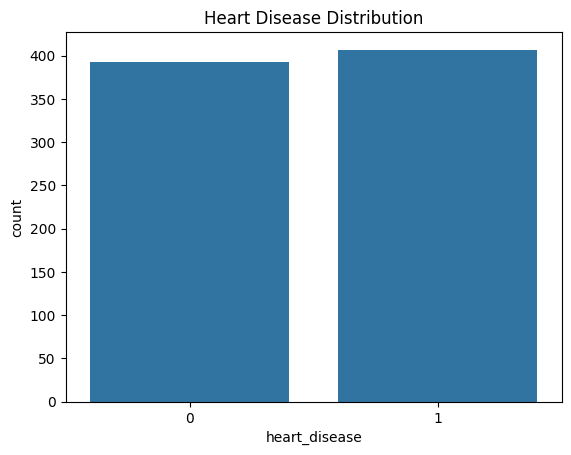

In [87]:
# 2. Exploratory Data Analysis 

import seaborn as sns
import matplotlib.pyplot as plt

 # a. Target class distribution plot
sns.countplot(x="heart_disease", data=df)
plt.title("Heart Disease Distribution")
plt.show()


It shows how many patients have disease(1) vs not(0)

<function matplotlib.pyplot.show(close=None, block=None)>

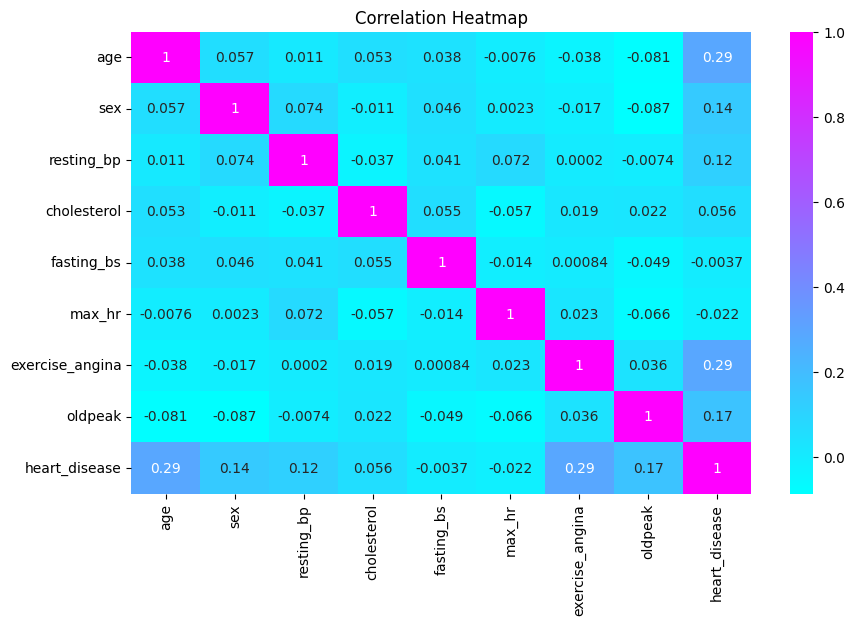

In [88]:
#b. Correlation Heatmap

plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="cool") 
plt.title("Correlation Heatmap")
plt.show

It show realatonship between different classes.
values close to 1 or -1 is considered as strong relationship

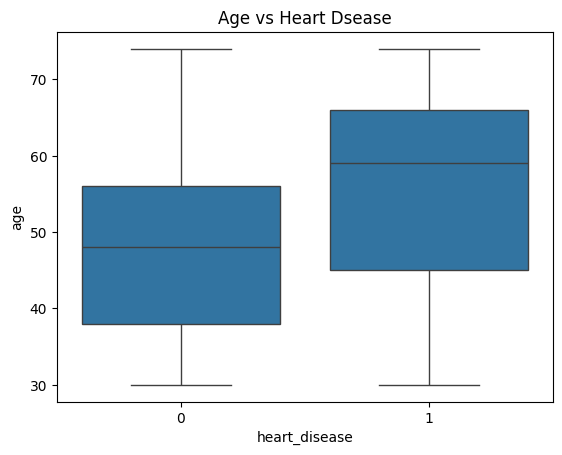

In [89]:
# c. Age vs Heart Disease
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Dsease")
plt.show()

It shows age distribution between different classes.

In [90]:
# 3. Data Preprocessing

 # step1. Missing values

# fill missing column with median
df.fillna(df.median(numeric_only=True), inplace=True)

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0
...,...,...,...,...,...,...,...,...,...,...,...,...
795,60,0,asymptomatic,147.0,197.0,0,left_ventricular_hypertrophy,152,0,3.1,flat,1
796,40,1,asymptomatic,125.0,257.0,0,normal,151,0,0.7,down,0
797,45,1,asymptomatic,120.0,192.0,0,st_t_wave_abnormality,128,0,2.7,up,1
798,37,0,non_anginal,112.0,303.0,0,left_ventricular_hypertrophy,145,0,0.9,flat,0


why median?
Median is better than mean in handling outliers.It keeps data safe rather dropping rows.

In [91]:
# step2. One hot encoding
df=pd.get_dummies(df, drop_first=True)

Converts categories into numerical

In [92]:
# Step3. Split dataset into train and test

X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]


# Step4. Train test split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Step5. Feature Scaling
from sklearn.preprocessing import StandardScaler    
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

1. stratify keeps class same in train & test.
2. Scaling makes all freatures same.

In [93]:
# 4. Model training

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#model
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# train
dt.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
gb.fit(X_train_scaled, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [94]:
# 5, Model Evaluation
from sklearn.metrics import confusion_matrix, classification_report

model = {"Decision Tree": dt,
         "Random Forest": rf,
         "Gradient Boosting": gb}

for name, model in model.items():
    print(f"/n{name}")

    y_pred = model.predict(X_test)

    print("Confusion Matrix:/n", confusion_matrix(y_test, y_pred))
    print("Classification Report:/n", classification_report(y_test, y_pred))

/nDecision Tree
Confusion Matrix:/n [[ 4 71]
 [ 6 79]]
Classification Report:/n               precision    recall  f1-score   support

           0       0.40      0.05      0.09        75
           1       0.53      0.93      0.67        85

    accuracy                           0.52       160
   macro avg       0.46      0.49      0.38       160
weighted avg       0.47      0.52      0.40       160

/nRandom Forest
Confusion Matrix:/n [[ 9 66]
 [ 1 84]]
Classification Report:/n               precision    recall  f1-score   support

           0       0.90      0.12      0.21        75
           1       0.56      0.99      0.71        85

    accuracy                           0.58       160
   macro avg       0.73      0.55      0.46       160
weighted avg       0.72      0.58      0.48       160

/nGradient Boosting
Confusion Matrix:/n [[19 56]
 [ 4 81]]
Classification Report:/n               precision    recall  f1-score   support

           0       0.83      0.25      0.39    

C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


Precision - How accurate positive predictions are
Recall - How many actual positives were found
F1-score - balance of precision & recall

In [95]:
# 6. Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grind = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10],}

grid = GridSearchCV(rf, param_grind, cv=5, scoring='f1')
grid.fit(X_train_scaled, y_train)

print("Best Parameters:/n", grid.best_params_)


Best Parameters:/n {'max_depth': 10, 'n_estimators': 100}


In [96]:
# Evaluate tuned model

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("confusion_matrix:/n", confusion_matrix(y_test, y_pred))
print("Classification Report:/n", classification_report(y_test, y_pred))

confusion_matrix:/n [[10 65]
 [ 0 85]]
Classification Report:/n               precision    recall  f1-score   support

           0       1.00      0.13      0.24        75
           1       0.57      1.00      0.72        85

    accuracy                           0.59       160
   macro avg       0.78      0.57      0.48       160
weighted avg       0.77      0.59      0.49       160



C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Conclusion

Untuned model performed better due to highest f1 score and balanced precision recall